In [101]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "Clean_Dataset.csv"

# Loading the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "shubhambathwal/flight-price-prediction",
  file_path,
)

df = df.rename(columns={"Unnamed: 0": "ID"}) #Renaming the first column to ID
df["route"] = df["source_city"] + " -> " + df["destination_city"] #adding a new column for route

Matplotlib is building the font cache; this may take a moment.


In [102]:
df.head()

,ID,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,route
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,Delhi -> Mumbai
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,Delhi -> Mumbai
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,Delhi -> Mumbai
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,Delhi -> Mumbai
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,Delhi -> Mumbai


In [103]:
df.size
df.shape
df.info()
df.shape
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
 12  route             300153 non-null  str    
dtypes: float64(1), int64(3), str(9)
memory usage: 29.8 MB


Index(['ID', 'airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price', 'route'],
      dtype='str')

In [105]:
df.drop(columns=['ID']).describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


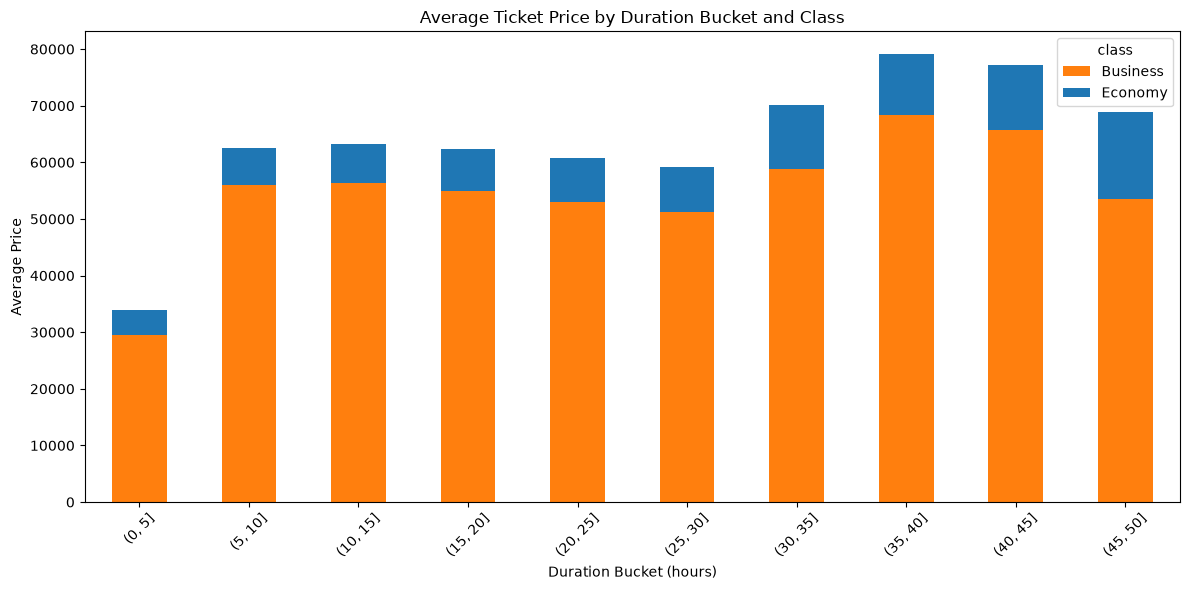

In [131]:
bucket_stops_price = (
    df.groupby(["duration_bucket", "class"], observed=True)["price"]
    .mean()
    .unstack("class")[["Business", "Economy"]]
)

fig, ax = plt.subplots(figsize=(12, 6))
bucket_stops_price.plot(
    kind="bar",
    stacked=True,
    color=["tab:orange", "tab:blue"],
    ax=ax,
)

ax.set_title("Average Ticket Price by Duration Bucket and Class")
ax.set_xlabel("Duration Bucket (hours)")
ax.set_ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


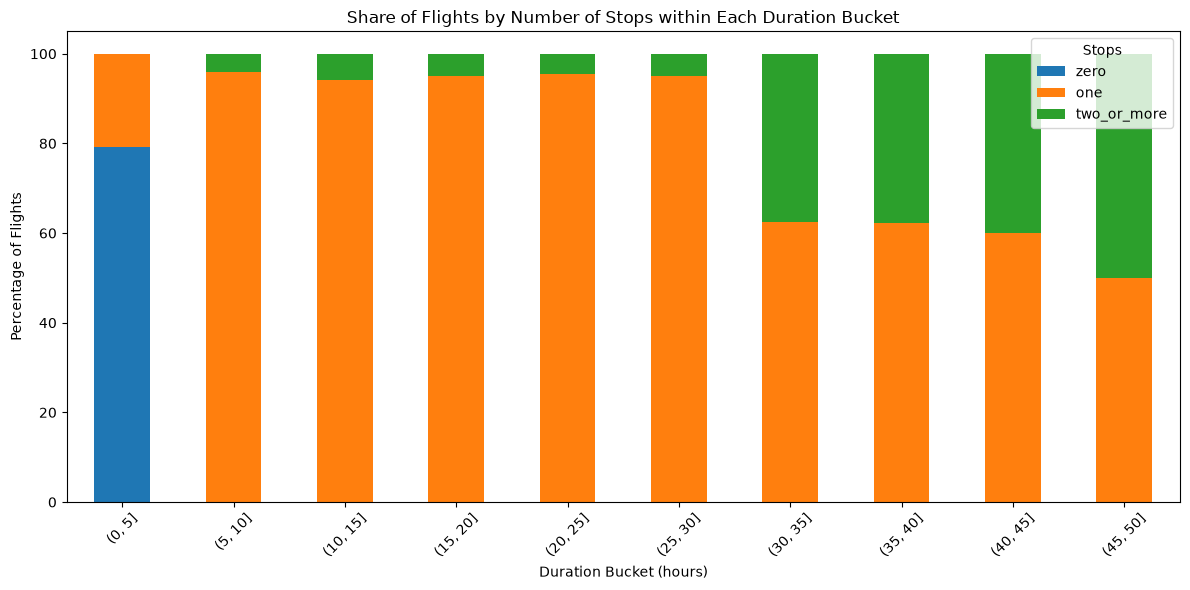

In [137]:
stops_pct = (
    pd.crosstab(df["duration_bucket"], df["stops"], normalize="index")[
        ["zero", "one", "two_or_more"]
    ]
    * 100
)

fig, ax = plt.subplots(figsize=(12, 6))
stops_pct.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Share of Flights by Number of Stops within Each Duration Bucket")
ax.set_xlabel("Duration Bucket (hours)")
ax.set_ylabel("Percentage of Flights")
ax.legend(title="Stops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

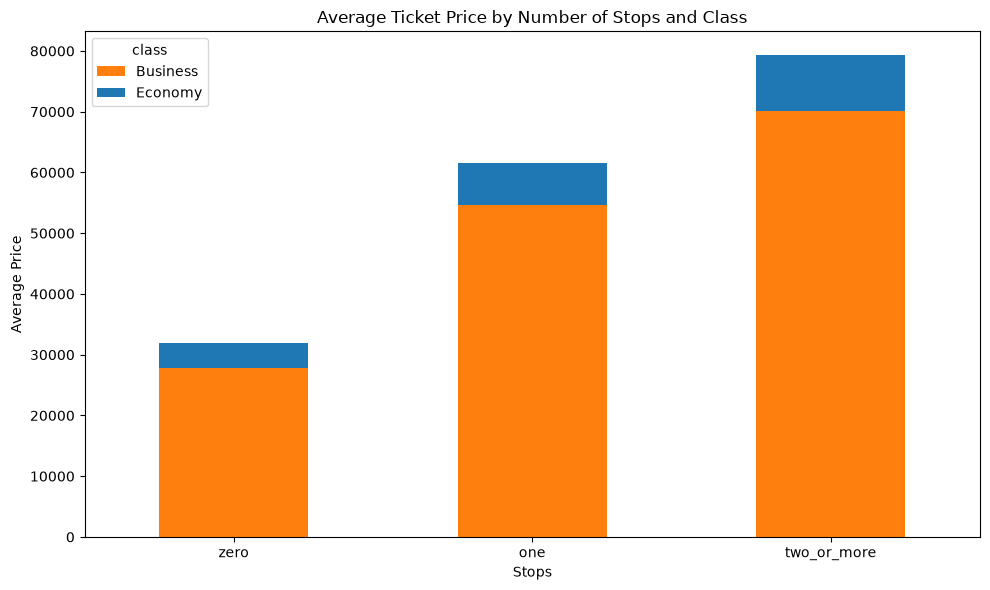

In [139]:
stops_class_price = (
    df.groupby(["stops", "class"], observed=True)["price"]
    .mean()
    .unstack("class")[["Business", "Economy"]]
    .reindex(["zero", "one", "two_or_more"])
)

fig, ax = plt.subplots(figsize=(10, 6))
stops_class_price.plot(
    kind="bar",
    stacked=True,
    color=["tab:orange", "tab:blue"],
    ax=ax,
)
ax.set_title("Average Ticket Price by Number of Stops and Class")
ax.set_xlabel("Stops")
ax.set_ylabel("Average Price")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

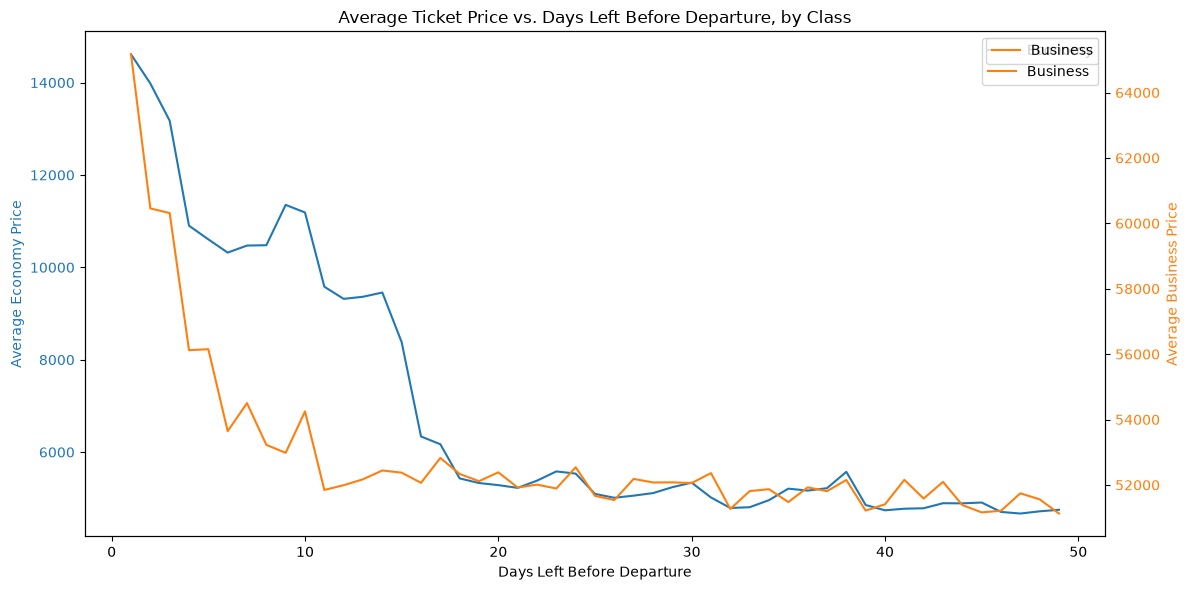

In [148]:
days_left_price = (
    df.groupby(["days_left", "class"], observed=True)["price"]
    .mean()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

sns.lineplot(
    data=days_left_price[days_left_price["class"] == "Economy"],
    x="days_left",
    y="price",
    color="tab:blue",
    label="Economy",
    ax=ax1,
)
sns.lineplot(
    data=days_left_price[days_left_price["class"] == "Business"],
    x="days_left",
    y="price",
    color="tab:orange",
    label="Business",
    ax=ax2,
)

ax1.set_xlabel("Days Left Before Departure")
ax1.set_ylabel("Average Economy Price", color="tab:blue")
ax2.set_ylabel("Average Business Price", color="tab:orange")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:orange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Average Ticket Price vs. Days Left Before Departure, by Class")
plt.tight_layout()
plt.show()
